<a href="https://colab.research.google.com/github/ktgirl38/CSC-402/blob/main/Group_Project_Katie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb #import seaborn sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.meta.per_cell_line.txt', sep='\t')


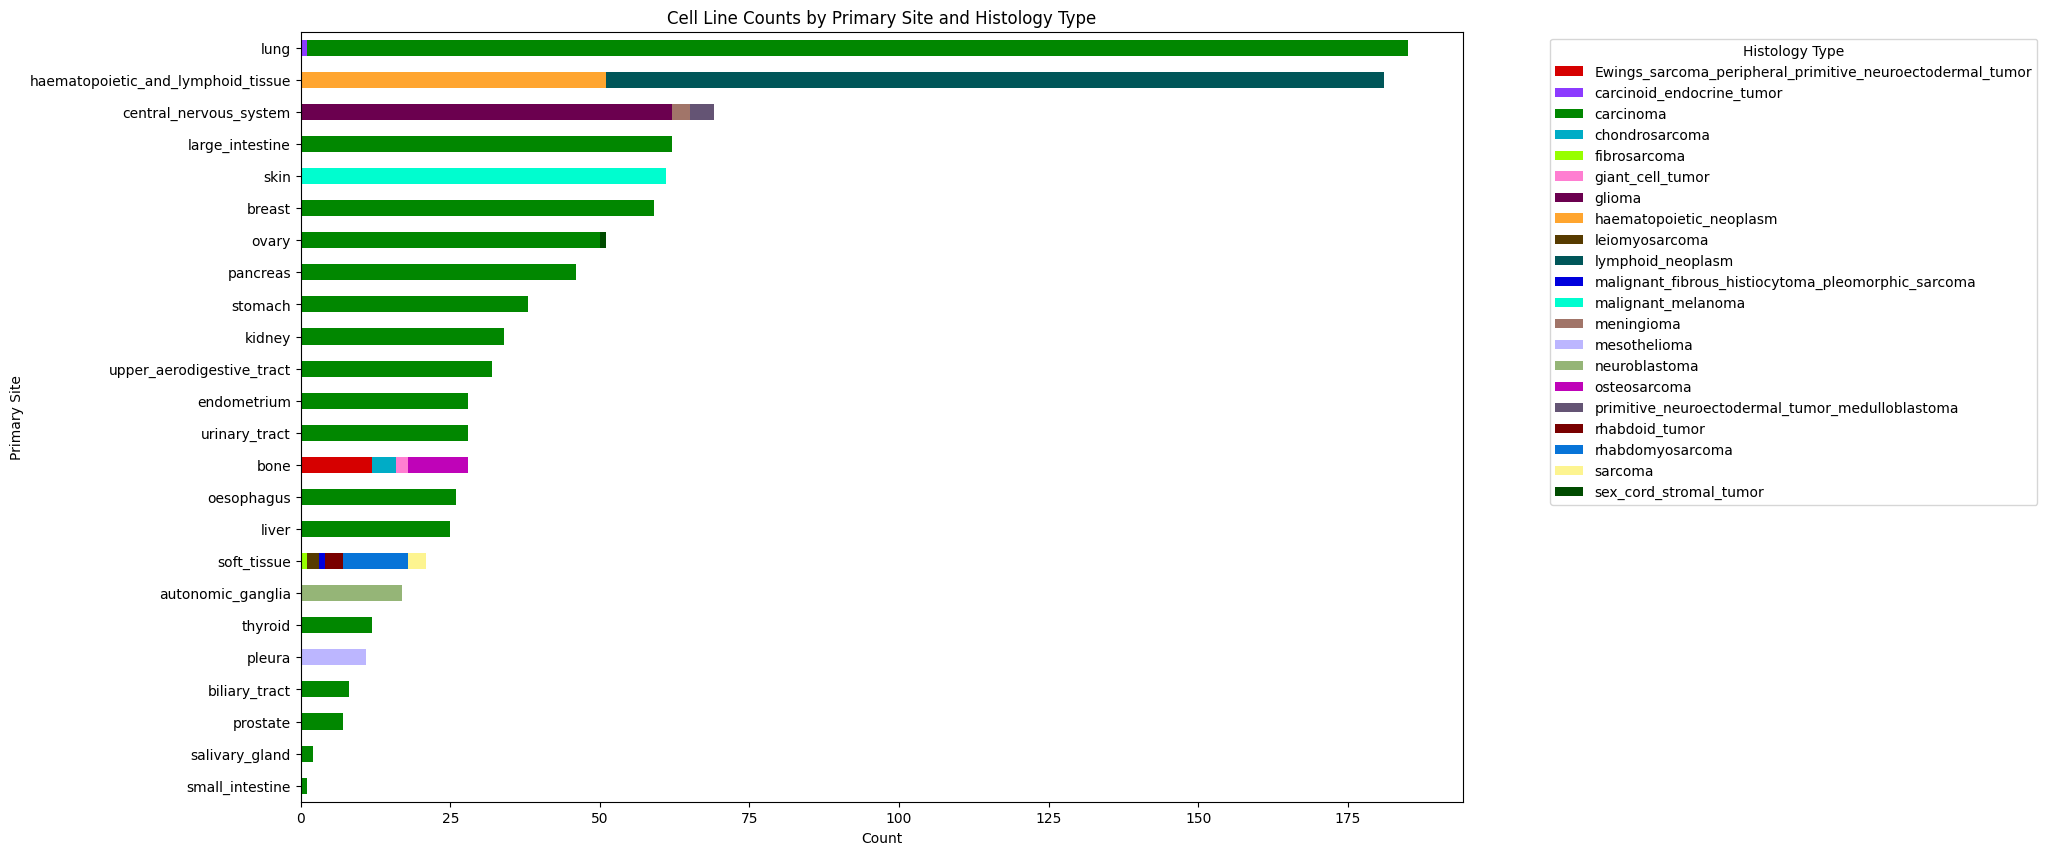

In [ ]:
import matplotlib.colors as cm
import colorcet as cc

df2=df.groupby(['ccle_primary_site', 'ccle_primary_hist']).size().reset_index()
pt=pd.pivot_table(df2, values=0, index='ccle_primary_site', columns='ccle_primary_hist', fill_value=0)
pt['total'] = pt.sum(axis=1)
pt = pt.sort_values('total', ascending=True)
pt = pt.drop(columns='total')

palette = sb.color_palette(cc.glasbey, n_colors=21)
selected_colormap = cm.ListedColormap(palette)

pt.plot(kind='barh', stacked=True, legend='Upper Right', figsize=(15, 10), colormap=selected_colormap)
plt.title('Cell Line Counts by Primary Site and Histology Type')
plt.xlabel('Count')
plt.xticks(rotation=0)
plt.ylabel('Primary Site')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1), title='Histology Type')
